In [2]:
import pandas as pd
import plotly.express as px
import json
from wordcloud import WordCloud
import ast
import matplotlib.pyplot as plt
import pickle

In [3]:
df = pd.read_csv('../../data/pp/preprocessed_properties_for_viz.csv')
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,total_area_sqft,bedrooms,bathrooms,balcony,floornum,...,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score,features,area_per_bedroom
0,Independent Builder Floor,"sushant lok phase 1, gurgaon",sector 43,3.75,13883,2701.0,4,4,2,1.0,...,1,0,0,1,south-east,Semi-Furnished,New Property,0.803312,"['Feng Shui / Vaastu Compliant', 'Water purifi...",675.250000
1,Independent House,"sohna road, gurgaon",sector 48,0.75,4167,1800.0,5,3,0,2.0,...,0,0,0,0,not available,Unfurnished,Moderately Old,0.000000,NaN,360.000000
2,Independent House,tata primanti,sector 72,8.50,18888,4500.0,4,4,3+,2.0,...,1,0,0,0,east,Unfurnished,Relatively New,1.364912,"['Water purifier', 'Centrally Air Conditioned'...",1125.000000
3,Flat,dlf ridgewood estate,sector 28,2.95,21532,1370.0,3,3,1,5.0,...,0,0,0,0,not available,Unfurnished,Old Property,0.079055,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",456.666667
4,Independent House,"behrampur, gurgaon",sector 71,0.41,3927,1044.0,3,2,2,1.0,...,0,0,0,0,north-west,Unfurnished,Relatively New,0.127547,['Water Storage'],348.000000


In [4]:
latlong = pd.read_csv('../../data/analytics_module/gurgaon_sectors_coordinates.csv')

In [5]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
113,sector 114,"28.5334° N, 77.0118° E"
114,sector 115,"28.5385° N, 77.0061° E"
115,gwal pahari,"28.4484° N, 77.0210° E"
116,farukhnagar,"28.4490° N, 76.8228° E"


In [6]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [7]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [8]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [9]:
df.shape

(5427, 21)

In [10]:
latlong.shape

(118, 4)

In [11]:
new_df = df.merge(latlong, on='sector')

In [12]:
new_df

,property_type,society,sector,price_in_cr,price_per_sqft,total_area_sqft,bedrooms,bathrooms,balcony,floornum,...,others,facing,furnishing_type,age_possession_category,luxury_score,features,area_per_bedroom,coordinates,latitude,longitude
0,Independent Builder Floor,"sushant lok phase 1, gurgaon",sector 43,3.75,13883,2701.0,4,4,2,1.0,...,1,south-east,Semi-Furnished,New Property,0.803312,"['Feng Shui / Vaastu Compliant', 'Water purifi...",675.250000,"28.4629° N, 77.0772° E",28.4629,77.0772
1,Independent House,"sohna road, gurgaon",sector 48,0.75,4167,1800.0,5,3,0,2.0,...,0,not available,Unfurnished,Moderately Old,0.000000,NaN,360.000000,"28.4177° N, 77.0359° E",28.4177,77.0359
2,Independent House,tata primanti,sector 72,8.50,18888,4500.0,4,4,3+,2.0,...,0,east,Unfurnished,Relatively New,1.364912,"['Water purifier', 'Centrally Air Conditioned'...",1125.000000,"28.4225° N, 77.0211° E",28.4225,77.0211
3,Flat,dlf ridgewood estate,sector 28,2.95,21532,1370.0,3,3,1,5.0,...,0,not available,Unfurnished,Old Property,0.079055,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",456.666667,"28.4728° N, 77.0865° E",28.4728,77.0865
4,Independent House,"behrampur, gurgaon",sector 71,0.41,3927,1044.0,3,2,2,1.0,...,0,north-west,Unfurnished,Relatively New,0.127547,['Water Storage'],348.000000,"28.4104° N, 77.0281° E",28.4104,77.0281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5418,Independent House,"sector 46, gurgaon",sector 46,5.15,35542,1449.0,6,6,2,3.0,...,0,north-east,Unfurnished,Old Property,0.742970,"['Water Storage', 'Recently Renovated', 'Natur...",241.500000,"28.4374° N, 77.0586° E",28.4374,77.0586
5419,Independent Builder Floor,dlf phase 1 ultra luxury builder floors,sector 26,8.75,15909,5500.0,5,6,2,1.0,...,0,north,Semi-Furnished,Relatively New,0.897896,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1100.000000,"28.4757° N, 77.1032° E",28.4757,77.1032
5420,Independent Builder Floor,dlf luxury builder floors,sector 25,5.55,14605,3800.0,4,5,2,3.0,...,1,north-east,Semi-Furnished,New Property,1.364912,"['Water purifier', 'Centrally Air Conditioned'...",950.000000,"28.4844° N, 77.0860° E",28.4844,77.0860
5421,Independent Builder Floor,ansal api esencia,sector 67,2.61,12253,2430.0,4,4,2,2.0,...,1,east,Semi-Furnished,Relatively New,1.364912,"['Water purifier', 'Centrally Air Conditioned'...",607.500000,"28.3859° N, 77.0608° E",28.3859,77.0608


In [13]:
new_df.isnull().sum()

property_type                0
society                      0
sector                       0
price_in_cr                  0
price_per_sqft               0
total_area_sqft              0
bedrooms                     0
bathrooms                    0
balcony                      0
floornum                     0
study_room                   0
servant_room                 0
store_room                   0
pooja_room                   0
others                       0
facing                       0
furnishing_type              0
age_possession_category      0
luxury_score                 0
features                   259
area_per_bedroom             0
coordinates                  0
latitude                     0
longitude                    0
dtype: int64

### 1. Sector Supply Intensity

In [14]:
sector_supply_df = new_df.groupby('sector').size().reset_index(name="listing_count").sort_values("listing_count", ascending=False)
sector_supply_df

,sector,listing_count
45,sector 43,219
29,sector 26,202
53,sector 50,193
2,sector 1,193
70,sector 67,182
...,...,...
33,sector 30,2
84,sector 80,2
81,sector 78,2
4,sector 101,1


In [15]:
fig_supply = px.bar(
    sector_supply_df,
    x="listing_count",
    y="sector",
    orientation="h",
    labels={
        "listing_count": "Number of Listings",
        "sector": "Sector"
    }
)

fig_supply.update_layout(
    height=600,
    yaxis={"categoryorder": "total ascending"}
)


In [16]:
group_df = new_df.groupby("sector", as_index=False).mean(numeric_only=True)[['sector','price_per_sqft','total_area_sqft','latitude','longitude']]

In [17]:
group_df.sort_values(by='sector', ascending= True)

,sector,price_per_sqft,total_area_sqft,latitude,longitude
0,bhondsi,6766.666667,1311.333333,28.3510,77.0615
1,gwal pahari,13170.000000,3533.200000,28.4484,77.0210
2,sector 1,16601.911917,3079.647668,28.3663,76.9456
3,sector 10,21030.230769,1439.692308,28.4537,77.0009
4,sector 101,11111.000000,540.000000,28.4672,76.9801
...,...,...,...,...,...
95,sector 91,13077.785714,2318.571429,28.4014,76.9225
96,sector 92,11093.522727,2131.715909,28.4079,76.9153
97,sector 93,11204.187500,1590.406250,28.4153,76.9326
98,sector 95,9850.812500,894.875000,28.4172,76.9081


In [18]:
new_df.to_csv(r'..\..\data\analytics_module\gurgaon_property_geomap.csv',index = False)

## WordCloud

In [19]:
features_df = pd.read_csv(r'..\..\data\analytics_module\wordcloud.csv')
features_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,super_built_up_area,built_up_area,carpet_area,plot_area,study_room,servant_room,store_room,pooja_room,others,age_possession_category
0,4 BHK Independent Builder Floor in Sushant Lok...,"sushant lok phase 1, gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,2701.0,NaN,NaN,NaN,0,1,0,0,1,New Property
1,"5 Bedroom House in Sohna Road, Gurgaon","sohna road, gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,NaN,1800.0,NaN,NaN,0,0,0,0,0,Undefined
2,"4 Bedroom House in Sector 72, Gurgaon",tata primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,NaN,NaN,NaN,4500.0,0,1,0,0,0,Relatively New
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,1370.0,NaN,NaN,NaN,0,0,0,0,0,Old Property
4,"3 Bedroom House in Behrampur, Gurgaon","behrampur, gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,NaN,NaN,NaN,1044.0,0,0,0,0,0,Relatively New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","sector 46, gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,NaN,NaN,NaN,1449.0,0,0,0,1,0,Old Property
5970,5 BHK Independent Builder Floor in DLF Phase 1...,dlf phase 1 ultra luxury builder floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,NaN,NaN,5500.0,NaN,1,1,1,1,0,Relatively New
5971,4 BHK Independent Builder Floor in DLF Phase 2...,dlf luxury builder floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,NaN,NaN,3800.0,NaN,1,1,0,1,1,New Property
5972,"4 BHK Independent Builder Floor in Sector 67, ...",ansal api esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,2430.0,NaN,NaN,NaN,0,1,0,1,1,Relatively New


In [20]:
wordcloud_df = features_df[
    ["sector", "features"]
].copy()


In [21]:
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [22]:
main

['Feng Shui / Vaastu Compliant',
 'Water purifier',
 'Lift(s)',
 'High Ceiling Height',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Visitor Parking',
 'Park',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water purifier',
 'Centrally Air Conditioned',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Fitness Centre / GYM',
 'Club house /

In [23]:
feature_text = ' '.join(main)

In [24]:
feature_text

'Feng Shui / Vaastu Compliant Water purifier Lift(s) High Ceiling Height False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Visitor Parking Park Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water purifier Centrally Air Conditioned Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Fitness Centre / GYM Club house / Community Center Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Maintenance Staff Swimming Pool Park Security Personnel Internet/wi-fi connectivity Shopping Centre 

In [25]:
pickle.dump(feature_text, open(r'..\..\data\analytics_module\feature_text.pkl','wb'))

In [26]:
wordcloud = WordCloud(width = 1000, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

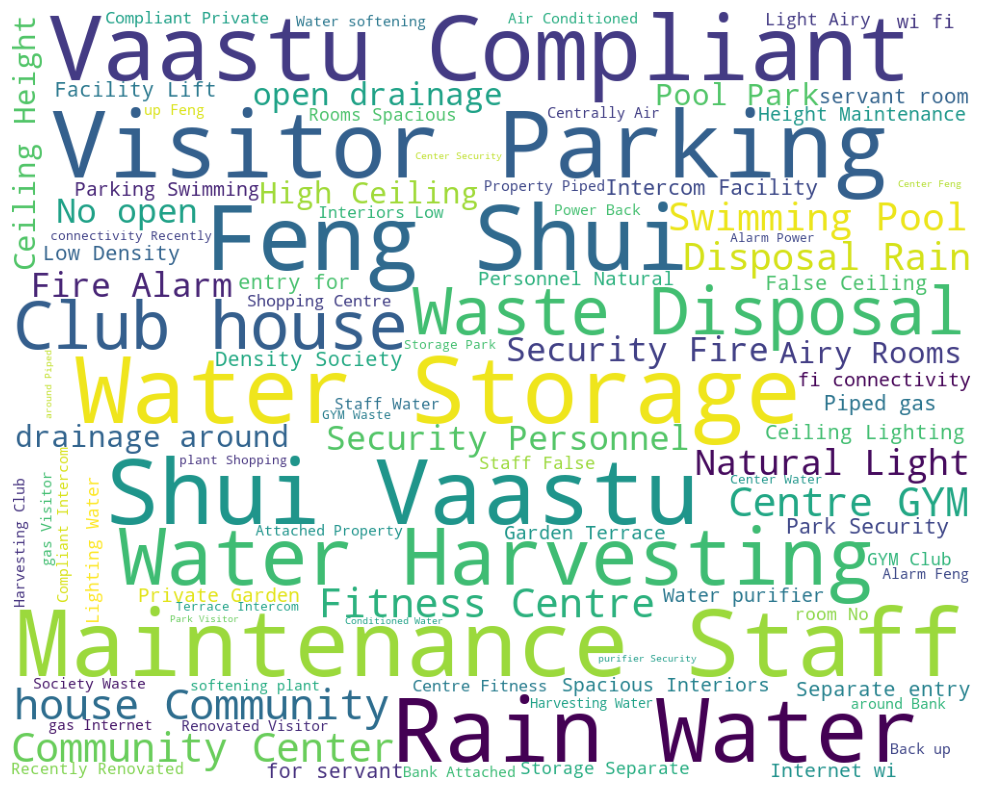

In [27]:
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud.to_image())
plt.axis("off")
plt.show()

## Summary 

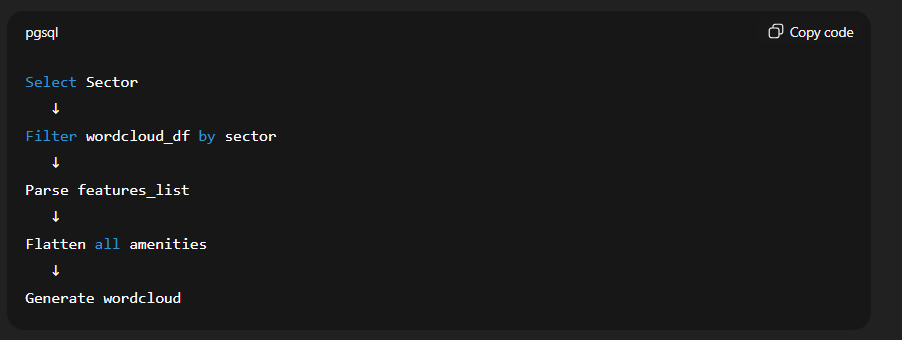


“Show dominant amenities for a sector, even if generic ones dominate.”

# 3. ScatterPlot

In [28]:
new_df

,property_type,society,sector,price_in_cr,price_per_sqft,total_area_sqft,bedrooms,bathrooms,balcony,floornum,...,others,facing,furnishing_type,age_possession_category,luxury_score,features,area_per_bedroom,coordinates,latitude,longitude
0,Independent Builder Floor,"sushant lok phase 1, gurgaon",sector 43,3.75,13883,2701.0,4,4,2,1.0,...,1,south-east,Semi-Furnished,New Property,0.803312,"['Feng Shui / Vaastu Compliant', 'Water purifi...",675.250000,"28.4629° N, 77.0772° E",28.4629,77.0772
1,Independent House,"sohna road, gurgaon",sector 48,0.75,4167,1800.0,5,3,0,2.0,...,0,not available,Unfurnished,Moderately Old,0.000000,NaN,360.000000,"28.4177° N, 77.0359° E",28.4177,77.0359
2,Independent House,tata primanti,sector 72,8.50,18888,4500.0,4,4,3+,2.0,...,0,east,Unfurnished,Relatively New,1.364912,"['Water purifier', 'Centrally Air Conditioned'...",1125.000000,"28.4225° N, 77.0211° E",28.4225,77.0211
3,Flat,dlf ridgewood estate,sector 28,2.95,21532,1370.0,3,3,1,5.0,...,0,not available,Unfurnished,Old Property,0.079055,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",456.666667,"28.4728° N, 77.0865° E",28.4728,77.0865
4,Independent House,"behrampur, gurgaon",sector 71,0.41,3927,1044.0,3,2,2,1.0,...,0,north-west,Unfurnished,Relatively New,0.127547,['Water Storage'],348.000000,"28.4104° N, 77.0281° E",28.4104,77.0281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5418,Independent House,"sector 46, gurgaon",sector 46,5.15,35542,1449.0,6,6,2,3.0,...,0,north-east,Unfurnished,Old Property,0.742970,"['Water Storage', 'Recently Renovated', 'Natur...",241.500000,"28.4374° N, 77.0586° E",28.4374,77.0586
5419,Independent Builder Floor,dlf phase 1 ultra luxury builder floors,sector 26,8.75,15909,5500.0,5,6,2,1.0,...,0,north,Semi-Furnished,Relatively New,0.897896,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1100.000000,"28.4757° N, 77.1032° E",28.4757,77.1032
5420,Independent Builder Floor,dlf luxury builder floors,sector 25,5.55,14605,3800.0,4,5,2,3.0,...,1,north-east,Semi-Furnished,New Property,1.364912,"['Water purifier', 'Centrally Air Conditioned'...",950.000000,"28.4844° N, 77.0860° E",28.4844,77.0860
5421,Independent Builder Floor,ansal api esencia,sector 67,2.61,12253,2430.0,4,4,2,2.0,...,1,east,Semi-Furnished,Relatively New,1.364912,"['Water purifier', 'Centrally Air Conditioned'...",607.500000,"28.3859° N, 77.0608° E",28.3859,77.0608


In [29]:
fig = px.scatter(data_frame= new_df, x = 'total_area_sqft', y = 'price_in_cr', color= 'bedrooms')
fig.update_layout(width=800,
    height=500

)

# 4. Pie Chart

In [30]:
fig = px.pie(data_frame= new_df, names= 'bedrooms', title= 'Total Bill Amount by Day')
fig.update_layout(width=800,
    height=500
)
fig.show()

# 5. Side by Side Box Plot Comparison - Bedroom vs Price

In [31]:
filtered_bedroom = new_df[new_df['bedrooms']<=4]
fig = px.box(data_frame= filtered_bedroom, x ='bedrooms', y = 'price_in_cr')
fig.update_layout(width=800,
    height=500)

1. The Core Objective

Choropleth Maps (Area-based) :

I wanted to visualize the real estate market 'temperature' of Gurugram by transforming individual property listings into an interactive Choropleth Map. The goal was to show average price trends and property sizes across different sectors, rather than just plotting individual points.

2. Sourcing the Geospatial "Skeleton"
"To get the sector boundaries, I used Overpass Turbo, which allows for direct querying of the OpenStreetMap (OSM) database. I wrote a query to extract all 'Relations' (polygons) named 'Sector' within the Gurugram boundary. This provided the GeoJSON file containing the physical shapes Plotly needs to render a choropleth."

3. The Data Transformation Pipeline
"This was the most challenging part of the project. I had to solve a Data Linkage problem:"

Aggregation: "I grouped my raw property data by sector to calculate the mean price_per_sqft and total_area_sqft, ensuring a 1:1 relationship between my data and the map areas."

4. Problem : Choropleths rely on perfect GeoJSON boundaries. I found that some OpenStreetMap data contained 'non-closed rings' or missing sector polygons, which led to 'blind spots' on the map. The Scatter Map ensures 100% data visibility because it only requires coordinates. 

Alternate Approach :

Scatter Maps (Point-based) :

Coordinate Merging: Joining my cleaned property dataset with a master 'Lat-Long' file for Gurugram sectors.

Visual Encoding: Encoding price_per_sqft onto a sequential color scale (like Viridis) and total_area_sqft onto the marker size.

The transition from Choropleth to Scatter Map was a deliberate choice to prioritize data accuracy and comprehensive coverage. It allowed me to visualize every sector in the dataset without being limited by the inconsistencies of third-party geographic boundary files. It resulted in a tool that is both highly accurate and highly performant
